In [21]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
import math

In [12]:
class quad(TypedDict):
    a:float
    b:float
    c:float
    d:float
    roots:list[float]

In [22]:
def show_equation(state:quad):
    print(f"{state['a']}x^2 + {state['b']}x + {state['c']}")
    return state

In [23]:
def calculate_discriminant(state:quad):
    state['d'] = state['b']**2-(4*state['a']*state['c'])
    return state

In [24]:
def real_roots(state: quad):
    r = math.sqrt(state["d"])
    state["roots"] = [
        (-state["b"] + r)/(2*state["a"]),
        (-state["b"] - r)/(2*state["a"])
    ]
    return state

In [25]:
def repeated_roots(state: quad):
    r = (-state["b"])/(2*state["a"])
    state["roots"] = [r]
    return state

In [26]:
def no_real_roots(state:quad):
    state['roots'] = []
    return state

In [27]:
# Need to define a routing function
def route_by_discriminant(state:quad):
    if state['d'] > 0:
        return "real_roots"
    elif state['d'] == 0:
        return "repeated_roots"
    else:
        return "no_real_roots"
   

In [28]:
graph = StateGraph(quad)
graph.add_node("show_equation",show_equation)
graph.add_node("calculate_discriminant",calculate_discriminant)
graph.add_node("no_real_roots",no_real_roots)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_roots",repeated_roots)

graph.add_edge(START, "show_equation")
graph.add_edge("show_equation","calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant", route_by_discriminant)
graph.add_edge("no_real_roots",END)
graph.add_edge("repeated_roots",END)
graph.add_edge("real_roots",END)

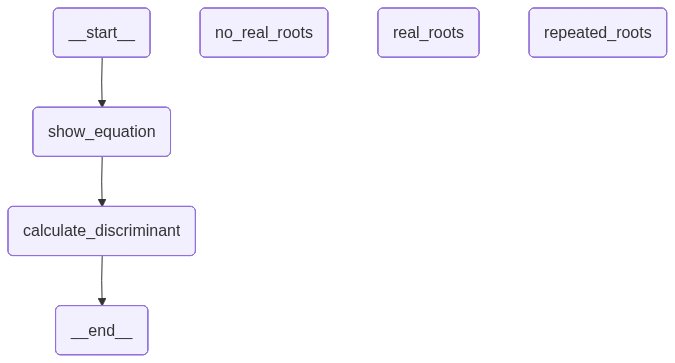

In [29]:
graph.compile()

In [31]:
app = graph.compile()

def run_test(name, state):
    print(f"\n=== {name} ===")
    result = app.invoke(state)
    print("Final state:", result)


In [32]:
run_test(
    "Two real roots",
    {"a": 1, "b": -3, "c": 2, "d": 0, "roots": []}
)
run_test(
    "Repeated root",
    {"a": 1, "b": -2, "c": 1, "d": 0, "roots": []}
)
run_test(
    "No real roots",
    {"a": 1, "b": 0, "c": 1, "d": 0, "roots": []}
)
run_test(
    "Linear equation edge case",
    {"a": 0, "b": 2, "c": -4, "d": 0, "roots": []}
)
run_test(
    "Large numbers",
    {"a": 1e6, "b": -3e6, "c": 2e6, "d": 0, "roots": []}
)



=== Two real roots ===
1x^2 + -3x + 2
Final state: {'a': 1, 'b': -3, 'c': 2, 'd': 1, 'roots': [2.0, 1.0]}

=== Repeated root ===
1x^2 + -2x + 1
Final state: {'a': 1, 'b': -2, 'c': 1, 'd': 0, 'roots': [1.0]}

=== No real roots ===
1x^2 + 0x + 1
Final state: {'a': 1, 'b': 0, 'c': 1, 'd': -4, 'roots': []}

=== Linear equation edge case ===
0x^2 + 2x + -4


ZeroDivisionError: float division by zero